In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "ayeshasiddiqa123/student-health",
    "student_mental_health_burnout_1M.csv"   # <-- actual file name inside dataset
)




/tmp/ipykernel_41763/4007411193.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-health' dataset.


In [2]:
df

,age,gender,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,screen_time,internet_usage,financial_stress,family_expectation,burnout_score,mental_health_index,risk_level,dropout_risk
0,23,Male,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,4.993801,4.983157,3.446626,3.586147,2.037344,7.074487,Low,1.746601
1,20,Male,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,3.862980,5.136124,2.814039,5.478666,0.000000,9.860204,Low,0.000000
2,29,Male,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,5.428880,3.058333,4.918515,6.068155,0.000000,7.626370,Low,0.696941
3,27,Male,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,6.304842,6.931147,6.915885,6.557540,7.227651,4.649042,High,5.380592
4,24,Male,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,4.903146,5.134903,4.382820,5.934779,0.000000,8.927394,Low,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,22,Female,3,5.784771,4.922653,79.292283,2.033221,1.238058,0.000000,8.214062,4.404825,9.013047,1.000000,1.664220,5.374860,4.875184,0.000000,8.815294,Low,0.000000
999996,20,Male,1,3.795347,4.706976,70.718819,4.144918,2.768193,1.405596,6.701671,2.664749,8.678769,2.641657,2.923180,5.100452,5.495558,1.166516,7.089896,Low,0.000000
999997,24,Female,3,8.814898,8.750319,79.121184,4.715533,4.138000,1.931592,6.569535,4.219224,4.881412,5.224459,3.855320,2.290888,6.792472,1.997088,6.292909,Low,1.172209
999998,29,Female,4,5.920859,6.678223,69.424255,5.553155,5.681447,1.366879,8.017232,3.634823,5.232852,2.668379,2.951508,5.885972,6.829679,2.731137,5.664240,Low,1.968401


In [27]:
df.shape

(1000000, 20)

In [ ]:
print(df.columns.tolist())

['age', 'gender', 'academic_year', 'study_hours_per_day', 'exam_pressure', 'academic_performance', 'stress_level', 'anxiety_score', 'depression_score', 'sleep_hours', 'physical_activity', 'social_support', 'screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score', 'mental_health_index', 'risk_level', 'dropout_risk']


In [3]:
df=df.drop(['screen_time', 'internet_usage', 'financial_stress', 'family_expectation', 'burnout_score','risk_level', 'dropout_risk'],axis=1)

In [ ]:
df.shape

(1000000, 13)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
academic_year,0
study_hours_per_day,0
exam_pressure,0
academic_performance,0
stress_level,0
anxiety_score,0
depression_score,0
sleep_hours,0


In [29]:
df['gender'].unique()
df['gender'].value_counts()

,count
gender,
Female,480070
Male,479643
Other,40287


In [4]:
df=pd.get_dummies(df, columns=['gender'])

In [5]:
# Convert only boolean columns to 0/1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [32]:
df.head()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,mental_health_index,gender_Female,gender_Male,gender_Other
0,23,2,5.596071,6.487218,68.411114,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,7.074487,0,1,0
1,20,3,5.597171,5.631481,67.682159,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,9.860204,0,1,0
2,29,2,2.580491,6.015297,58.372363,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,7.626370,0,1,0
3,27,4,4.607208,6.684005,68.925653,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,4.649042,0,1,0
4,24,4,2.186569,4.010945,69.141915,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,8.927394,0,1,0


In [ ]:
df.isnull().sum()

,0
age,0
academic_year,0
study_hours_per_day,0
exam_pressure,0
academic_performance,0
stress_level,0
anxiety_score,0
depression_score,0
sleep_hours,0
physical_activity,0


In [6]:
true_duplicates = df[df.duplicated(keep='first')]
true_duplicates

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,mental_health_index,gender_Female,gender_Male,gender_Other


In [7]:
df=df.drop_duplicates(keep='first')


In [35]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['age', 'academic_year', 'study_hours_per_day', 'exam_pressure',
       'academic_performance', 'stress_level', 'anxiety_score',
       'depression_score', 'sleep_hours', 'physical_activity',
       'social_support', 'mental_health_index', 'gender_Female', 'gender_Male',
       'gender_Other'],
      dtype='object')

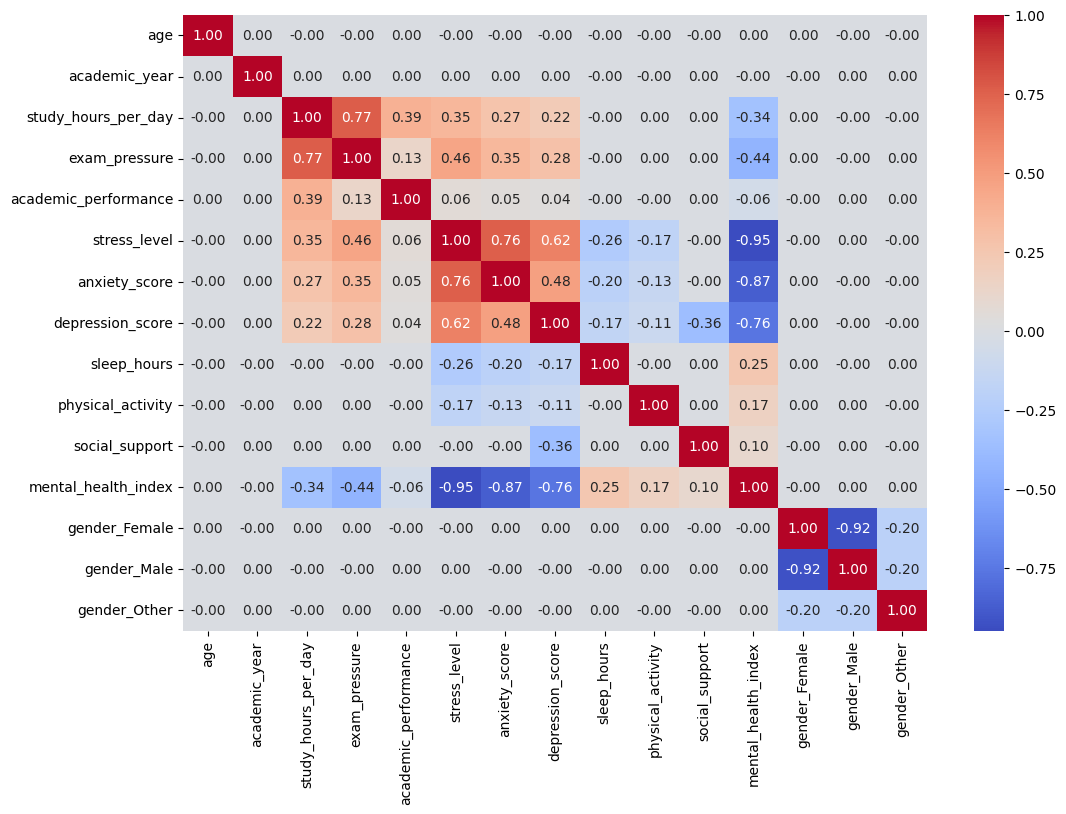

In [8]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [9]:
from sklearn.decomposition import PCA
academic_cols = ['study_hours_per_day', 'exam_pressure', 'academic_performance']


In [10]:
pca_academic=PCA(n_components=1)
df['academic_factors']=pca_academic.fit_transform(df[academic_cols])

In [ ]:
df.head()

,age,academic_year,study_hours_per_day,exam_pressure,academic_performance,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,mental_health_index,gender_Female,gender_Male,gender_Other,academic_factors
0,23,2,5,6,68,4,2,1,6,2,6,7,0,1,0,-2.367326
1,20,3,5,5,67,0,0,0,7,3,0,9,0,1,0,-3.402552
2,29,2,2,6,58,3,2,0,8,3,6,7,0,1,0,-12.696718
3,27,4,4,6,68,6,4,4,4,2,2,4,0,1,0,-2.520238
4,24,4,2,4,69,1,1,0,5,4,4,8,0,1,0,-1.935320


In [11]:
df = df.drop(columns=['study_hours_per_day', 'exam_pressure', 'academic_performance'])

In [40]:
df.shape

(1000000, 13)

In [41]:
df.head(10)

,age,academic_year,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,mental_health_index,gender_Female,gender_Male,gender_Other,academic_factors
0,23,2,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,7.074487,0,1,0,-2.439295
1,20,3,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,9.860204,0,1,0,-3.199704
2,29,2,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,7.626370,0,1,0,-12.833351
3,27,4,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,4.649042,0,1,0,-2.074112
4,24,4,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,8.927394,0,1,0,-2.361528
5,29,3,5.464786,1.720314,2.313338,6.574379,0.000000,3.928159,6.603990,1,0,0,-2.099077
6,21,3,2.989919,1.445026,0.000000,3.660558,1.975417,7.048037,8.370524,1,0,0,4.498285
7,23,2,5.007514,2.725366,0.782428,7.355030,0.000000,4.270020,6.944656,1,0,0,10.137812
8,26,4,5.802609,4.451598,2.034520,5.157029,2.138839,3.340810,5.733121,0,1,0,6.436097
9,19,3,4.307115,2.435479,1.127562,6.281727,0.991039,9.161838,7.208242,1,0,0,2.847014


In [12]:
df['academic_factors']=df['academic_factors'].astype(int)

In [74]:
df.head(10)

,age,academic_year,stress_level,anxiety_score,depression_score,sleep_hours,physical_activity,social_support,mental_health_index,gender_Female,gender_Male,gender_Other,academic_factors
0,23,2,4.116950,2.275713,1.986730,6.880545,2.728861,6.470080,7.074487,0,1,0,-2
1,20,3,0.349489,0.000000,0.000000,7.463339,3.690866,0.000000,9.860204,0,1,0,-3
2,29,2,3.476177,2.425201,0.851996,8.946670,3.296720,6.901725,7.626370,0,1,0,-12
3,27,4,6.778843,4.512425,4.285645,4.571380,2.065480,2.349857,4.649042,0,1,0,-2
4,24,4,1.854595,1.102558,0.000000,5.989324,4.026504,4.512921,8.927394,0,1,0,-2
5,29,3,5.464786,1.720314,2.313338,6.574379,0.000000,3.928159,6.603990,1,0,0,-2
6,21,3,2.989919,1.445026,0.000000,3.660558,1.975417,7.048037,8.370524,1,0,0,4
7,23,2,5.007514,2.725366,0.782428,7.355030,0.000000,4.270020,6.944656,1,0,0,10
8,26,4,5.802609,4.451598,2.034520,5.157029,2.138839,3.340810,5.733121,0,1,0,6
9,19,3,4.307115,2.435479,1.127562,6.281727,0.991039,9.161838,7.208242,1,0,0,2


In [13]:
corr_with_target = df.corr()['mental_health_index'].sort_values(ascending=False)
print(corr_with_target)

mental_health_index    1.000000
sleep_hours            0.250408
physical_activity      0.165397
social_support         0.102367
age                    0.000946
gender_Other           0.000748
gender_Male            0.000060
gender_Female         -0.000355
academic_year         -0.001332
academic_factors      -0.078492
depression_score      -0.763197
anxiety_score         -0.868666
stress_level          -0.949393
Name: mental_health_index, dtype: float64


In [14]:
df_sample = df.sample(n=50000, random_state=42)

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


In [41]:
X=df.drop(['mental_health_index', 'stress_level','anxiety_score'], axis=True)

In [42]:
X_sample=df_sample.drop(['mental_health_index', 'stress_level','anxiety_score'], axis=True)

In [18]:
y=df['mental_health_index']

In [43]:
y_sample=df_sample['mental_health_index']

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
from sklearn.model_selection import train_test_split
X_sample_train, X_sample_test, y_sample_train, y_sample_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

In [46]:
LinearModel=LinearRegression()
LinearModel.fit(X_train,y_train)
LinearPredict=LinearModel.predict(X_test)


In [47]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
r2 = r2_score(y_test, LinearPredict)
r2

0.6393916337776708

In [48]:
#too slow on huge datasets

KNNModel=KNeighborsRegressor(n_neighbors=3)
KNNModel.fit(X_sample_train,y_sample_train)
KNNPredict=KNNModel.predict(X_sample_test)
r2_score(y_sample_test,KNNPredict)

0.44938122086973864

In [49]:
TreeModel=DecisionTreeRegressor()
TreeModel.fit(X_train,y_train)
TreePredict=TreeModel.predict(X_test)
r2_score(y_test,TreePredict)

0.26629241557819305

In [50]:
ForestModel=RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
ForestModel.fit(X_sample_train,y_sample_train)
ForestPredict=ForestModel.predict(X_test)
r2_score(y_test,ForestPredict)

0.6584201016267367

In [51]:
importance=ForestModel.feature_importances_
features=X_sample.columns
df_importance = pd.DataFrame({
    'Feature': features,
    'Importance (%)': (importance * 100).round(2)
}).sort_values(by='Importance (%)', ascending=False)

df_importance

,Feature,Importance (%)
2,depression_score,84.65
5,social_support,7.18
3,sleep_hours,3.43
4,physical_activity,2.48
9,academic_factors,1.14
0,age,0.62
1,academic_year,0.26
6,gender_Female,0.09
7,gender_Male,0.08
8,gender_Other,0.07


In [52]:
X_sample.columns

Index(['age', 'academic_year', 'depression_score', 'sleep_hours',
       'physical_activity', 'social_support', 'gender_Female', 'gender_Male',
       'gender_Other', 'academic_factors'],
      dtype='object')

In [66]:
X_sample['Outdoors']=X_sample['physical_activity']+X_sample['social_support']
X_sample['Social_Ratio'] = X_sample['social_support'] / (X_sample['depression_score'] + 1)
X_sample_train, X_sample_test, y_sample_train, y_sample_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)
ForestModel.fit(X_sample_train, y_sample_train)

RandomForestRegressor(max_depth=10, n_estimators=50, n_jobs=-1, random_state=42)

In [67]:
r2_score(y_sample_test, ForestModel.predict(X_sample_test))

0.646738075768525

In [68]:
importance=ForestModel.feature_importances_
features=X_sample.columns
df_importance = pd.DataFrame({
    'Feature': features,
    'Importance (%)': (importance * 100).round(2)
}).sort_values(by='Importance (%)', ascending=False)

df_importance

,Feature,Importance (%)
2,depression_score,84.29
5,social_support,6.12
3,sleep_hours,3.27
4,physical_activity,1.97
11,Social_Ratio,1.27
10,Outdoors,1.11
9,academic_factors,1.02
0,age,0.55
1,academic_year,0.22
6,gender_Female,0.07


In [69]:
import joblib
# Save the actual ForestModel you trained in cell 66
joblib.dump(ForestModel, 'wellbeing_model.pkl')

['wellbeing_model.pkl']